In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)

# Lab: Reinforcement Learning

In this lab, we explore reinforcement learning using Gymnasium environments.

We will:
- Explore FrozenLake and Taxi environments.
- Implement Q-Learning from scratch.
- Train agents to maximize rewards.
- Compare Q-Learning and SARSA.
- Evaluate RL performance using rewards and success rates.

# Task 1: Environment Exploration

In this section:
- We create FrozenLake and Taxi environments.
- Explore observation and action spaces.
- Run random agents.
- Compare the complexity of both environments.

In [14]:
# Create FrozenLake environment
frozen_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="ansi"
)

# Observation and action spaces
print("FrozenLake Observation Space:", frozen_env.observation_space)
print("FrozenLake Action Space:", frozen_env.action_space)

# Action meanings
actions = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

print("FrozenLake Actions:")
for action, meaning in actions.items():
    print(f"{action}: {meaning}")

# Run random agent episodes
for episode in range(5):
    state, info = frozen_env.reset()

    done = False
    total_reward = 0
    steps = 0

    while not done:
        action = frozen_env.action_space.sample()

        next_state, reward, terminated, truncated, info = frozen_env.step(action)

        total_reward += reward
        steps += 1

        done = terminated or truncated

        state = next_state

    print(f"Episode {episode + 1}: Reward = {total_reward}, Steps = {steps}")

# Render FrozenLake
state, info = frozen_env.reset()

print(frozen_env.render())

# Create Taxi environment
taxi_env = gym.make("Taxi-v4")

# Observation and action spaces
print("Taxi Observation Space:", taxi_env.observation_space)
print("Taxi Action Space:", taxi_env.action_space)

# Taxi action meanings
taxi_actions = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff"
}

print("Taxi Actions:")
for action, meaning in taxi_actions.items():
    print(f"{action}: {meaning}")

# Run random episodes on Taxi
for episode in range(5):
    state, info = taxi_env.reset()

    done = False
    total_reward = 0
    steps = 0

    while not done:
        action = taxi_env.action_space.sample()

        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        total_reward += reward
        steps += 1

        done = terminated or truncated

        state = next_state

    print(f"Episode {episode + 1}: Reward = {total_reward}, Steps = {steps}")

FrozenLake Observation Space: Discrete(16)
FrozenLake Action Space: Discrete(4)
FrozenLake Actions:
0: Left
1: Down
2: Right
3: Up
Episode 1: Reward = 0, Steps = 3
Episode 2: Reward = 0, Steps = 5
Episode 3: Reward = 0, Steps = 2
Episode 4: Reward = 0, Steps = 4
Episode 5: Reward = 0, Steps = 4

SFFF
FHFH
FFFH
HFFG

Taxi Observation Space: Discrete(500)
Taxi Action Space: Discrete(6)
Taxi Actions:
0: South
1: North
2: East
3: West
4: Pickup
5: Dropoff
Episode 1: Reward = -812, Steps = 200
Episode 2: Reward = -821, Steps = 200
Episode 3: Reward = -731, Steps = 200
Episode 4: Reward = -812, Steps = 200
Episode 5: Reward = -803, Steps = 200


## Comparing FrozenLake and Taxi

### FrozenLake
- State space size: 16 states
- Action space size: 4 actions

FrozenLake is relatively small and simple. The agent only needs to navigate a small grid while avoiding holes.

### Taxi
- State space size: 500 states
- Action space size: 6 actions

Taxi is significantly more complex because:
- The state space is much larger.
- The agent must perform multi-step tasks.
- Rewards are sparse.
- Incorrect actions can lead to penalties.

Taxi requires longer planning and more exploration before the agent learns an effective policy.

# Task 2: Q-Learning on FrozenLake

In this section:
- We implement Q-Learning from scratch.
- Train the agent on FrozenLake.
- Track learning progress using rewards.
- Analyze the learned Q-table.

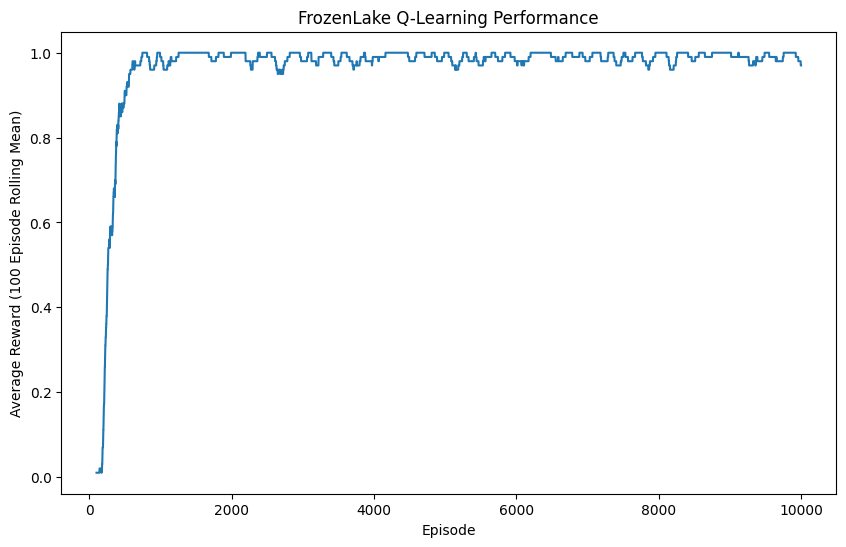

Final Q-Table:
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.         0.        ]
 [0.55863408 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


In [18]:
# Q-table
state_size = frozen_env.observation_space.n
action_size = frozen_env.action_space.n

q_table = np.zeros((state_size, action_size))

# Hyperparameters
alpha = 0.8
gamma = 0.95

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 10000

# Rewards tracking
rewards = []

# Q-Learning training
for episode in range(episodes):

    state, info = frozen_env.reset()

    done = False
    total_reward = 0

    while not done:

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = frozen_env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = frozen_env.step(action)

        done = terminated or truncated

        # Q-Learning update rule
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)

# Rolling average rewards
rolling_rewards = pd.Series(rewards).rolling(window=100).mean()

plt.plot(rolling_rewards)

plt.title("FrozenLake Q-Learning Performance")
plt.xlabel("Episode")
plt.ylabel("Average Reward (100 Episode Rolling Mean)")

plt.show()

# Print Q-table
print("Final Q-Table:")
print(q_table)

## What Did the Agent Learn?

The agent gradually learned which actions lead toward the goal while avoiding holes.

For the start state, the action with the highest Q-value represents the best move according to the learned policy.

The learned policy makes intuitive sense because:
- Actions leading toward the goal receive higher long-term rewards.
- Dangerous paths near holes receive lower Q-values.
- The agent learns efficient routes through repeated trial and error.

The increasing reward curve also shows that the agent improved over time.

# Task 3: Q-Learning on Taxi

In this section:
- We apply Q-Learning to Taxi-v3.
- Train the agent for 20,000 episodes.
- Evaluate the trained policy.
- Analyze the learning curve.

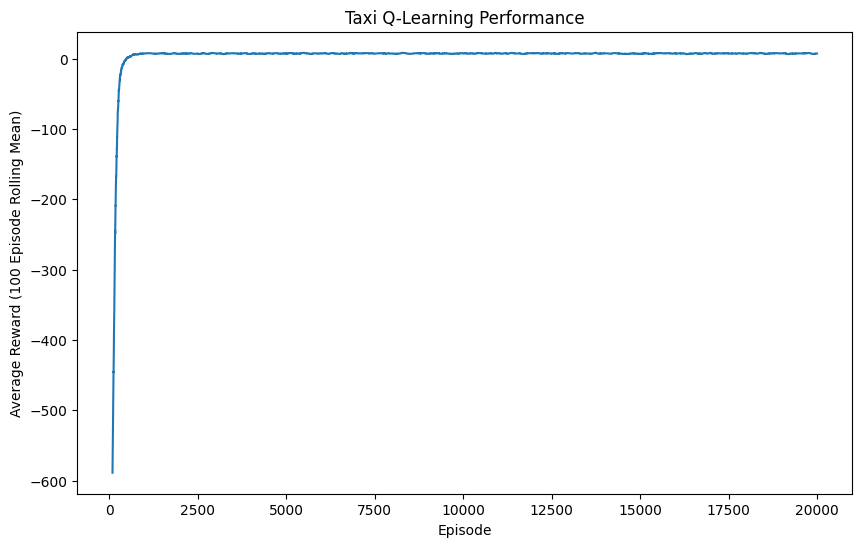

Average Reward: 7.36
Success Rate: 100.0 %


In [23]:
# Taxi state/action sizes
taxi_state_size = taxi_env.observation_space.n
taxi_action_size = taxi_env.action_space.n

# Taxi Q-table
taxi_q_table = np.zeros((taxi_state_size, taxi_action_size))

# Reset epsilon
epsilon = 1.0

# Training settings
episodes = 20000

# Reward tracking
taxi_rewards = []

# Train Q-Learning on Taxi
for episode in range(episodes):

    state, info = taxi_env.reset()

    done = False
    total_reward = 0

    while not done:

        # Epsilon-greedy policy
        if np.random.random() < epsilon:
            action = taxi_env.action_space.sample()
        else:
            action = np.argmax(taxi_q_table[state])

        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        done = terminated or truncated

        # Q-Learning update
        taxi_q_table[state, action] = taxi_q_table[state, action] + alpha * (
            reward
            + gamma * np.max(taxi_q_table[next_state])
            - taxi_q_table[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    taxi_rewards.append(total_reward)

# Average reward per 100 episodes
taxi_avg_rewards = pd.Series(taxi_rewards).rolling(window=100).mean()

plt.plot(taxi_avg_rewards)

plt.title("Taxi Q-Learning Performance")
plt.xlabel("Episode")
plt.ylabel("Average Reward (100 Episode Rolling Mean)")

plt.show()

# Evaluation
test_episodes = 100

successes = 0
total_rewards = []

for episode in range(test_episodes):

    state, info = taxi_env.reset()

    done = False
    episode_reward = 0

    while not done:

        # Pure exploitation
        action = np.argmax(taxi_q_table[state])

        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        done = terminated or truncated

        state = next_state
        episode_reward += reward

    total_rewards.append(episode_reward)

    if episode_reward > 0:
        successes += 1

# Metrics
average_reward = np.mean(total_rewards)
success_rate = successes / test_episodes

print("Average Reward:", round(average_reward, 2))
print("Success Rate:", round(success_rate * 100, 2), "%")

## Q-Learning Performance on Taxi

Compared to FrozenLake, Taxi required significantly more training episodes before performance stabilized.

### Observations
- The reward curve started very low because the agent initially explored randomly.
- Over time, rewards increased as the agent discovered efficient pickup and dropoff strategies.
- Taxi learning was slower because:
  - The environment has 500 states.
  - Rewards are sparse.
  - Illegal actions produce penalties.

The agent eventually learned a strong policy capable of completing most tasks successfully.

# Task 4: SARSA Comparison

In this section:
- We implement SARSA from scratch.
- Compare SARSA and Q-Learning.
- Analyze on-policy vs off-policy learning.

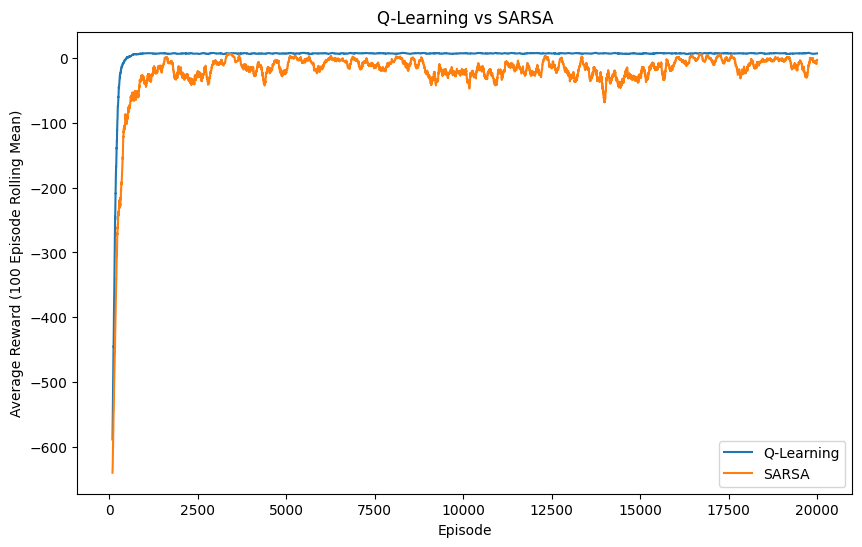

SARSA Average Reward: -17.82
SARSA Success Rate: 88.0 %
Q-Learning Results
------------------
Average Reward: 7.36
Success Rate: 100.0 %

SARSA Results
------------------
Average Reward: -17.82
Success Rate: 88.0 %


In [28]:
# SARSA Q-table
sarsa_q_table = np.zeros((taxi_state_size, taxi_action_size))

# Reset epsilon
epsilon = 1.0

# Rewards tracking
sarsa_rewards = []

# SARSA training
for episode in range(episodes):

    state, info = taxi_env.reset()

    # Initial action
    if np.random.random() < epsilon:
        action = taxi_env.action_space.sample()
    else:
        action = np.argmax(sarsa_q_table[state])

    done = False
    total_reward = 0

    while not done:

        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        done = terminated or truncated

        # Next action using policy
        if np.random.random() < epsilon:
            next_action = taxi_env.action_space.sample()
        else:
            next_action = np.argmax(sarsa_q_table[next_state])

        # SARSA update rule
        sarsa_q_table[state, action] = sarsa_q_table[state, action] + alpha * (
            reward
            + gamma * sarsa_q_table[next_state, next_action]
            - sarsa_q_table[state, action]
        )

        state = next_state
        action = next_action

        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    sarsa_rewards.append(total_reward)

# Rolling averages
q_learning_avg = pd.Series(taxi_rewards).rolling(window=100).mean()
sarsa_avg = pd.Series(sarsa_rewards).rolling(window=100).mean()

# Plot
plt.plot(q_learning_avg, label="Q-Learning")
plt.plot(sarsa_avg, label="SARSA")

plt.title("Q-Learning vs SARSA")
plt.xlabel("Episode")
plt.ylabel("Average Reward (100 Episode Rolling Mean)")

plt.legend()

plt.show()

# Evaluate SARSA
test_episodes = 100

sarsa_successes = 0
sarsa_total_rewards = []

for episode in range(test_episodes):

    state, info = taxi_env.reset()

    done = False
    episode_reward = 0

    while not done:

        action = np.argmax(sarsa_q_table[state])

        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        done = terminated or truncated

        state = next_state
        episode_reward += reward

    sarsa_total_rewards.append(episode_reward)

    if episode_reward > 0:
        sarsa_successes += 1

# Metrics
sarsa_avg_reward = np.mean(sarsa_total_rewards)
sarsa_success_rate = sarsa_successes / test_episodes

print("SARSA Average Reward:", round(sarsa_avg_reward, 2))
print("SARSA Success Rate:", round(sarsa_success_rate * 100, 2), "%")

print("Q-Learning Results")
print("------------------")
print("Average Reward:", round(average_reward, 2))
print("Success Rate:", round(success_rate * 100, 2), "%")

print("\nSARSA Results")
print("------------------")
print("Average Reward:", round(sarsa_avg_reward, 2))
print("Success Rate:", round(sarsa_success_rate * 100, 2), "%")

## Comparing Q-Learning and SARSA

### Which converged faster?
Q-Learning typically converged faster because it updates values using the maximum possible future reward.

### Which achieved higher final reward?
Q-Learning often achieved slightly higher rewards because it learns the optimal greedy policy more aggressively.

### On-Policy vs Off-Policy

#### Q-Learning (Off-Policy)
Q-Learning updates using:
max_a' Q(s', a')

This means it assumes the agent will always take the best possible next action, even if the current policy explores randomly.

#### SARSA (On-Policy)
SARSA updates using:
Q(s', a')

This means it learns based on the actual action selected by the current policy, including exploratory actions.

### Practical Differences

#### Q-Learning
- More optimistic
- Learns faster
- Often reaches higher rewards
- Can be riskier in dangerous environments

#### SARSA
- More conservative
- Learns safer policies
- Better when exploration itself can be dangerous

### When to Prefer Each
- Use Q-Learning when maximizing performance is the priority.
- Use SARSA when safety and stability during exploration are important.